### Librerie

In [1]:
import os
import torch
from torch.utils.data import Dataset
from torch.utils.data import TensorDataset
import pandas as pd
import numpy as np
import cv2
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch.nn.functional as F


### Funzioni di Normalizzazione e di Controllo

In [2]:
class Normalize01(torch.nn.Module):
    """Normalizza i valori di un tensore tra 0 e 1."""
    def __init__(self):
        super().__init__()

    def forward(self, img):
        min_val, max_val = img.min(), img.max()
        return (img - min_val) / (max_val - min_val) if max_val > min_val else torch.zeros_like(img)

    def __repr__(self):
        return self.__class__.__name__ + '()'

La classe Normalize01 è un modulo PyTorch riutilizzabile che normalizza un tensore (tipicamente un’immagine) per portare tutti i suoi valori tra 0 e 1. Utile nel preprocessing dei dati per reti neurali.

In [3]:
def check_tensor_range(img):
    """ Controlla se i valori del tensore sono nel range [0,1] dopo ToTensor. """
    if img.min() < 0 or img.max() > 1:
        print("Warning: Tensor values are out of range [0,1] after ToTensor")

Questa funzione controlla che tutti i valori di img (un tensore) siano compresi tra 0 e 1. Se anche un solo valore è fuori da questo intervallo, stampa un warning. Non restituisce niente (None), fa solo un controllo "di debug".

In [4]:
def lambda_check_range(x):
    return (check_tensor_range(x), x)[1]

Chiama check_tensor_range(x), ma restituisce comunque x. In pratica esegue un controllo con effetto collaterale (print), ma non altera il valore. Permette di integrare il controllo (funzione precedente) in una pipeline, senza modificarne il comportamento.

### Classe PollinateDataset

In [5]:
class PollinateDataset(Dataset):
    def __init__(self, csv_file=None, dataset_folder=None, channels=('T', 'M', 'N'),
                 selected_ids=None, transform=None, df=None):
        if df is not None:
            self.df = df
        elif csv_file is not None:
            self.df = pd.read_csv(csv_file)
        else:
            raise ValueError("Devi fornire almeno csv_file o df")

        self.dataset_folder = dataset_folder
        self.channels = channels
        self.transform = transform
        self.min_size = (100, 100)

        if selected_ids is not None:
            self.df = self.df[self.df['folder'].isin(selected_ids)]

    def __len__(self):
        return len(self.df)

    def pad_image_to_min_size(self, image, min_size=(100, 100)):
        """Aggiunge padding all'immagine se è più piccola delle dimensioni minime richieste."""
        h, w = image.shape[:2]
        pad_h = max(0, min_size[0] - h)
        pad_w = max(0, min_size[1] - w)

        if pad_h > 0 or pad_w > 0:
            # Calcola il padding su ogni lato per centrare l'immagine
            top = pad_h // 2
            bottom = pad_h - top
            left = pad_w // 2
            right = pad_w - left

            image = cv2.copyMakeBorder(image, top, bottom, left, right, cv2.BORDER_CONSTANT, value=0)

        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sample_id = str(row['folder'])
        label = row['class']
        folder_path = os.path.join(self.dataset_folder, sample_id)

        imgs = []
        for ch in self.channels:
            path = os.path.join(folder_path, f"{sample_id}_{ch}.npy")
            img = np.load(path)
            img = self.pad_image_to_min_size(img, self.min_size)
            imgs.append(img)

        img_stack = np.stack(imgs, axis=0)

        # Convert to float32 and normalize to [0,1] if not done already
        img_tensor = torch.from_numpy(img_stack).float()
        if self.transform:
            img_tensor = self.transform(img_tensor)
        else:
            #img_tensor = torch.from_numpy(img_stack).float()
            if img_tensor.max() > 1.0:
                img_tensor /= 255.0

        return row['folder'], img_tensor, label

**Init:**
Carica il DataFrame da CSV.
Se selected_ids è passato, filtra le righe del DataFrame (non lo useremo).
Imposta self.min_size = (100, 100) per garantire una dimensione minima delle immagini.



**Len:**
Restituisce il numero di campioni nel dataset (quanti folder sono presenti nel DataFrame filtrato).

**pad_image_to_min_size:** Controlla se l'immagine è più piccola di min_size.
Se sì, aggiunge padding nero (valore 0) per centrarla, usando cv2.copyMakeBorder() per il padding.

**getitem:**
1. Ottiene la riga del DataFrame per l'indice idx.
2. Carica le immagini .npy corrispondenti ai canali specificati
3. Applica padding a ciascuna immagine se troppo piccola.
4. Impila le immagini in un array NumPy: shape → (C, H, W).
5. Converte in tensore float32 (torch.from_numpy(...).float()).
6. Se è stata fornita una transform, la applica.
7. Se non c'è transform e i valori sono > 1.0, normalizza in [0,1] dividendo per 255.
8. Restituisce folder (id campione), img_tensor (tensore multicanale normalizzato e trasformato) e label (etichetta associata)

### Main

In [6]:
dataset_folder = r"C:\Users\Fabio\Desktop\Magistrale\Machine_Learning\esercizi\knime\3_Contest"
channels = ('T', 'M', 'N') #da modificare in base alla scelta dei canali
train_transform = transforms.Compose([
    transforms.Lambda(lambda_check_range),
    transforms.Resize((224, 224)),  # Porta tutto a 224x224 per il modello (ATTENZIONE: Da modificare in base alla scelta della soluzione)
    Normalize01()
])
train_dataset = PollinateDataset(os.path.join(dataset_folder,'train.csv'), os.path.join(dataset_folder, "train"), channels, transform=train_transform)


In [7]:
print(f"Numero totale di campioni: {len(train_dataset)}")

# Analisi su un esempio
folder_id, img_tensor, label = train_dataset[0]
print(f"ID campione: {folder_id}")
print(f"Forma del tensore immagine: {img_tensor.shape}")
print(f"Tipo del tensore: {type(img_tensor)}")
print(f"Tipo dati contenuti: {img_tensor.dtype}")
print(f"Etichetta associata: {label}")

Numero totale di campioni: 6798
ID campione: 000_117
Forma del tensore immagine: torch.Size([3, 224, 224])
Tipo del tensore: <class 'torch.Tensor'>
Tipo dati contenuti: torch.float32
Etichetta associata: 1


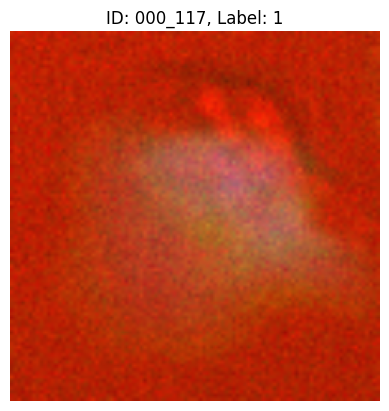

In [8]:
img_np = img_tensor.numpy()
if img_np.shape[0] == 1:
    # Se canale singolo, togli dimensione canale
    img_to_show = img_np[0]
elif img_np.shape[0] == 3:
    # Trasponi [C,H,W] -> [H,W,C]
    img_to_show = np.transpose(img_np, (1, 2, 0))
else:
    # Per altri casi, mostra il primo canale
    img_to_show = img_np[0]

plt.imshow(img_to_show, cmap='gray')
plt.title(f"ID: {folder_id}, Label: {label}")
plt.axis('off')
plt.show()

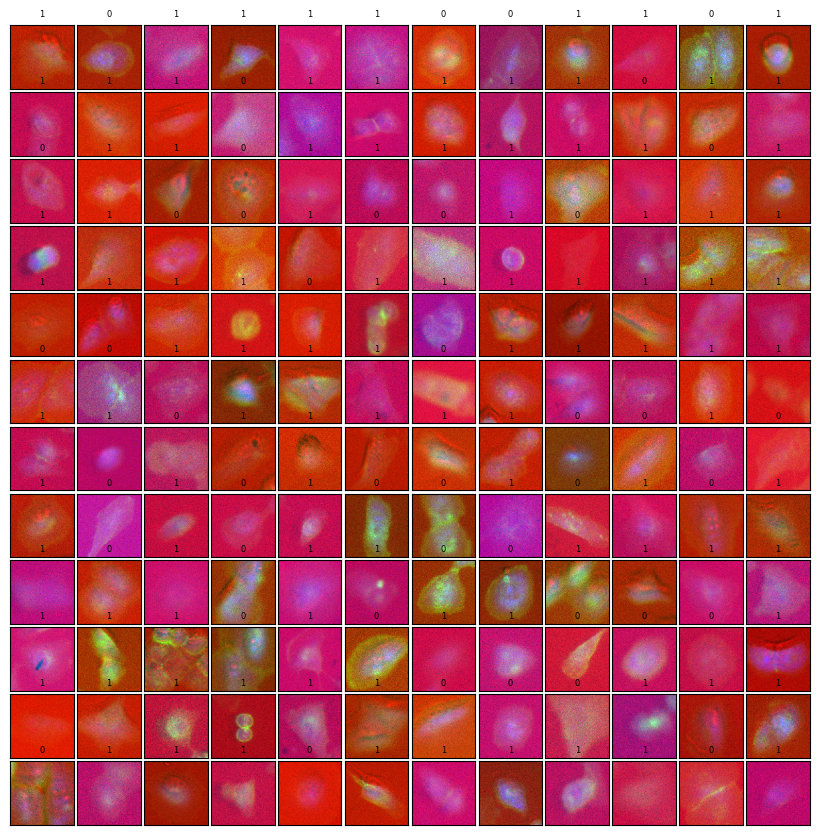

In [9]:
fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for i in range(min(144, len(train_dataset))):  # fino a 144 o numero totale campioni
    folder_id, img_tensor, label = train_dataset[i]
    img_np = img_tensor.numpy()
    # Trasponi i canali per matplotlib (C,H,W) -> (H,W,C)
    if img_np.shape[0] == 1:
        img_to_show = img_np[0]
        cmap = 'gray'
    else:
        img_to_show = np.transpose(img_np, (1, 2, 0))
        cmap = None  # se RGB, non serve cmap
    ax = fig.add_subplot(12, 12, i + 1, xticks=[], yticks=[])
    ax.imshow(img_to_show, cmap=cmap, interpolation='nearest')
    ax.set_title(str(label), fontsize=6)
plt.show()

Training dataset length: 5438
Validation dataset length: 680
Testing dataset length: 680


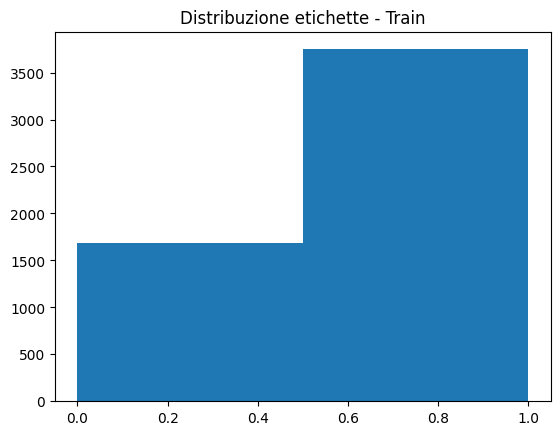

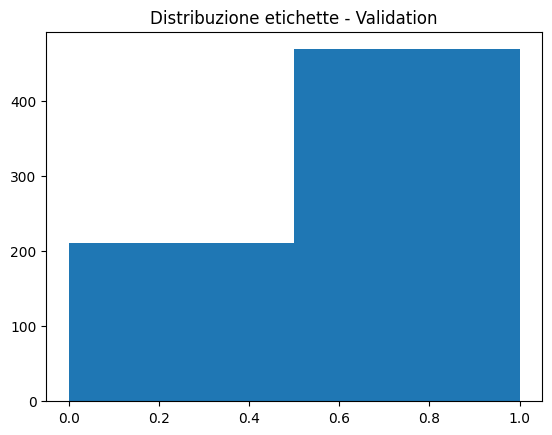

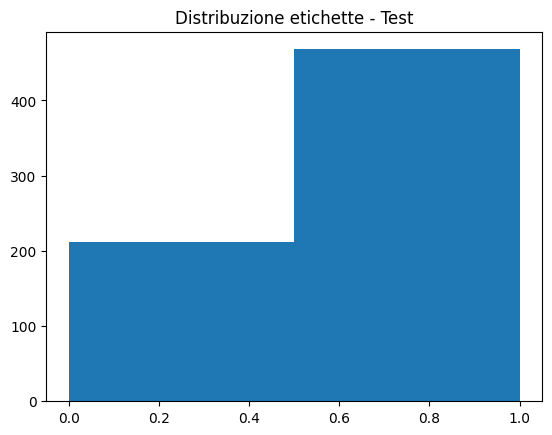

In [10]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Estrai tutti gli ID delle cartelle e le rispettive etichette dal dataframe
all_ids = train_dataset.df['folder'].values
all_labels = train_dataset.df['class'].values

# Prima suddivisione: 80% train, 20% restante
train_ids, remain_ids, train_labels, remain_labels = train_test_split(
    all_ids, all_labels, test_size=0.20, shuffle=True, stratify=all_labels, random_state=42
)

# Seconda suddivisione: 50% validazione, 50% test dal restante 20%
val_ids, test_ids, val_labels, test_labels = train_test_split(
    remain_ids, remain_labels, test_size=0.50, shuffle=True, stratify=remain_labels, random_state=42
)

# Crea i dataset con gli ID selezionati
train_dataset_split = PollinateDataset(os.path.join(dataset_folder, 'train.csv'), os.path.join(dataset_folder, "train"), channels, selected_ids=train_ids, transform=train_transform)
val_dataset = PollinateDataset(os.path.join(dataset_folder, 'train.csv'), os.path.join(dataset_folder, "train"), channels, selected_ids=val_ids, transform=train_transform)
test_dataset = PollinateDataset(os.path.join(dataset_folder, 'train.csv'), os.path.join(dataset_folder, "train"), channels, selected_ids=test_ids, transform=train_transform)

# Stampa dimensioni
print("Training dataset length:", len(train_dataset_split))
print("Validation dataset length:", len(val_dataset))
print("Testing dataset length:", len(test_dataset))

# Visualizzazione delle distribuzioni
plt.hist(train_labels, bins=len(np.unique(train_labels)))
plt.title("Distribuzione etichette - Train")
plt.show()

plt.hist(val_labels, bins=len(np.unique(val_labels)))
plt.title("Distribuzione etichette - Validation")
plt.show()

plt.hist(test_labels, bins=len(np.unique(test_labels)))
plt.title("Distribuzione etichette - Test")
plt.show()

In [11]:
from torch.utils.data import TensorDataset

def create_tensor_dataset(dataset):
    images = []
    labels = []
    for _, img_tensor, label in dataset:
        images.append(img_tensor.unsqueeze(0))  # aggiunge dimensione batch
        labels.append(label)
    
    images_tensor = torch.cat(images, dim=0)
    labels_tensor = torch.tensor(labels)

    return TensorDataset(images_tensor, labels_tensor)

# Crea i TensorDataset dalle istanze di PollinateDataset
dataset_train = create_tensor_dataset(train_dataset_split)
dataset_val = create_tensor_dataset(val_dataset)
dataset_test = create_tensor_dataset(test_dataset)


In [12]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) #8+2-3+1 = 8
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 2 * 2, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> [batch, 32, 4, 4]
        x = self.pool(F.relu(self.conv2(x)))   # -> [batch, 64, 2, 2]
        x = x.view(-1, 64 * 2 * 2)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

'''
# Define the MLP architecture
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()


        self.block = nn.Sequential( nn.Linear(input_dim, 32),
                                    nn.ReLU(),
                                    #nn.Linear(4096, 1024),
                                    #nn.ReLU(),
                                    #nn.Dropout(0.4),
                                    #nn.Linear(1024, 256),
                                    #nn.ReLU(),
                                    nn.Linear(32, 10)
                                )

    def forward(self, x):   #FORWARD STEP
        out = self.block(x)
        return out

100 bach size 10 = 10 batch
100 bach size 20 = 5 batch
'''

# Define the training function
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train()
    train_acc = 0.0
    train_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device).long()
        optimizer.zero_grad()
        output = model(data) #forward
        loss = criterion(output, target)  #calcolo loss
        loss.backward() #calcolo gradienti
        optimizer.step() #agg pesi

        train_loss += loss.item()
        train_acc += (output.argmax(dim=1) == target).sum().item()
    train_acc /= len(train_loader.dataset)
    train_loss /= len(train_loader.dataset)
    return train_loss, train_acc

# Define the validation function
def validate(model, device, val_loader, criterion):
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device).long()
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
            val_acc += (output.argmax(dim=1) == target).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc /= len(val_loader.dataset)
    return val_loss, val_acc

In [ ]:
input_dim = 64
output_dim = 10
lr = 0.01
num_epochs = 5
batch_size = 25088


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model, device, optimizer, and criterion
model = CNN().to(device) #MLP(input_dim, output_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr = lr) #optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Load the training and validation data loaders

# Initialize the lists to store the training and validation losses and accuracies
train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_loss = 0.0

# Train the model
for epoch in range(num_epochs):
    # CREATE BATCHES
    train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(dataset_val, batch_size=batch_size, shuffle=True)
    #1. WORK ON TRAIN SET
    # FOR EACH BATCH b:
    #     FORWARD STEP -> y_pred = MLP(b)
    #     COMPUTE THE LOSS -> Loss = criterion(y_pred, label)
    #     COMPUTE THE GRADIENTS
    #     UPDATE THE NETWORK
    #2. WORK ON VALIDATION SET
    # FOR EACH BATCH b:
    #     FORWARD STEP -> y_pred = MLP(b)
    #     COMPUTE THE LOSS -> Loss = criterion(y_pred, label)
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion, epoch)
    val_loss, val_acc = validate(model, device, val_loader, criterion)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.4f}')

    if epoch == 0 or val_loss<best_loss:
      best_loss = val_loss
      torch.save(model.state_dict(),  'best_weights.pth')

# Plot the training curves
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

NameError: name 'optim' is not defined